In [250]:
from gaussian_mixture_score_creation import *

In [264]:
config = load_config(config_path='E:/GitHub/aggrigator_experiments/spatial/spatial_configs/lidc.toml')
#config = load_config(config_path='E:/GitHub/aggrigator_experiments/spatial/spatial_configs/gta.toml')
dataset_name = config['dataset']['dataset_name']

print(f"Loaded configuration for dataset: '{dataset_name}'")

paths = {
    'id_spatial': config['paths'].get('id_csv_path_spatial'),
    'ood_spatial': config['paths'].get('ood_csv_path_spatial'),
    'id_magnitude': config['paths'].get('id_csv_path_magnitude'),
    'ood_magnitude': config['paths'].get('ood_csv_path_magnitude')
}

base_filename = config['paths'].get('base_filename', 'fingerprints')

Loaded configuration for dataset: 'lidc'


In [273]:
id_spatial = load_spatial_fingerprints(paths['id_spatial'], base_filename)
ood_spatial = load_spatial_fingerprints(paths['ood_spatial'], base_filename)
id_magnitude = load_magnitude_fingerprints(paths['id_magnitude'], base_filename)
ood_magnitude = load_magnitude_fingerprints(paths['ood_magnitude'], base_filename)

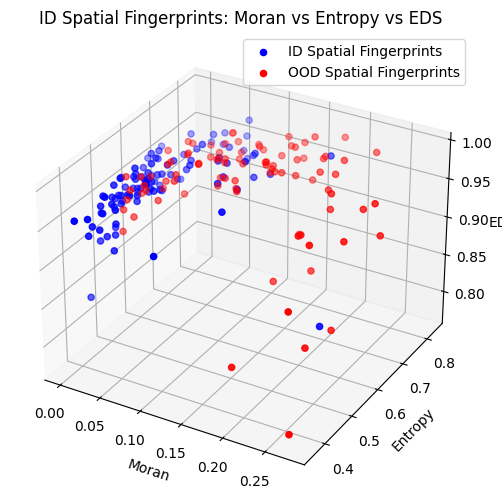

In [266]:
import matplotlib.pyplot as plt

# plot spatial fingerprints
plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.scatter(id_spatial['moran'], id_spatial['entropy'], id_spatial['eds'], label='ID Spatial Fingerprints', color='blue')
ax.scatter(ood_spatial['moran'], ood_spatial['entropy'], ood_spatial['eds'], label='OOD Spatial Fingerprints', color='red')
ax.set_xlabel('Moran')
ax.set_ylabel('Entropy')
ax.set_zlabel('EDS')
ax.legend()
ax.set_title('ID Spatial Fingerprints: Moran vs Entropy vs EDS')
plt.show()

In [274]:
# add id_spatial index name uq_map_name
id_spatial.index.name = 'uq_map_name'
id_magnitude.index = id_magnitude.index.astype('str')
id_spatial.index = id_spatial.index.astype('str')

# give a different name to ood spatial and ood magnitude
ood_spatial.index.name = 'uq_map_name'
ood_magnitude.index = ood_magnitude.index.astype('str')
ood_spatial.index = ood_spatial.index.astype('str')

ood_spatial.index = [f"ood_{idx}" for idx in ood_spatial.index]
ood_magnitude.index = [f"ood_{idx}" for idx in ood_magnitude.index]

In [271]:
id_magnitude
# remove 0s before index
id_magnitude.index = id_magnitude.index.str.lstrip('0')

In [275]:
# join id_spatial and id_magnitude via the index uq_map_name
#id_magnitude.set_index('uq_map_name', inplace=True)
id_fingerprints = id_spatial.join(id_magnitude)
ood_fingerprints = ood_spatial.join(ood_magnitude)
all_fingerprints = pd.concat([id_fingerprints, ood_fingerprints], axis=0)
all_fingerprints

,moran,entropy,eds,mean,above_threshold_mean_0.3,above_threshold_mean_0.5,above_threshold_mean_0.7,above_threshold_mean_0.9,above_threshold_mean_0.95,above_quantile_mean_0.3,...,above_quantile_mean_0.7,above_quantile_mean_0.9,above_quantile_mean_fg_ratio,patch_aggregation_10,patch_aggregation_20,patch_aggregation_40,patch_aggregation_80,patch_aggregation_100,"class_mean_w_equal_weights_configurable_{'include_background': False, 'ignore_index': 0}","class_mean_weighted_by_occurrence_configurable_{'include_background': False, 'ignore_index': 0}"
0027_03,0.022847,0.465252,0.930062,0.001731,0.505600,0.619659,0.0,0.0,0.0,0.001731,...,0.005770,0.017295,0.179233,0.069079,0.017370,0.004432,0.001108,0.000709,0.128374,0.128374
0027_04,0.000398,0.389996,0.949855,0.000828,0.420001,0.529599,0.0,0.0,0.0,0.000828,...,0.002759,0.008269,0.120560,0.032469,0.008476,0.002119,0.000530,0.000339,0.058713,0.058713
0028_00,0.019711,0.562870,0.960811,0.002445,0.551237,0.621267,0.0,0.0,0.0,0.002445,...,0.008149,0.024426,0.285001,0.098506,0.024633,0.006259,0.001565,0.001001,0.105313,0.105313
0031_01,0.013786,0.455285,0.964707,0.001193,0.491222,0.575484,0.0,0.0,0.0,0.001193,...,0.003976,0.011919,0.186825,0.048847,0.012217,0.003054,0.000764,0.000489,0.129041,0.129041
0038_00,0.007587,0.428172,0.933175,0.002832,0.530217,0.636586,0.0,0.0,0.0,0.002832,...,0.009440,0.028297,0.181202,0.112732,0.028292,0.007162,0.001813,0.001160,0.104680,0.104680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ood_0923_01,0.025843,0.507502,0.961669,0.004387,0.505722,0.604183,0.0,0.0,0.0,0.004387,...,0.014622,0.043832,0.142495,0.087448,0.044569,0.011232,0.002808,0.001797,0.086747,0.086747
ood_0977_00,0.071602,0.739452,0.982207,0.004371,0.526635,0.611768,0.0,0.0,0.0,0.004371,...,0.014566,0.043664,0.297892,0.168597,0.044753,0.011189,0.002797,0.001790,0.141312,0.141312
ood_0984_02,0.034993,0.609928,0.967687,0.003039,0.497456,0.641827,0.0,0.0,0.0,0.003039,...,0.010130,0.030364,0.175242,0.110353,0.031123,0.007781,0.001945,0.001245,0.114928,0.114928
ood_0984_03,0.174267,0.676948,0.897581,0.014686,0.465557,0.622567,0.0,0.0,0.0,0.014686,...,0.048947,0.146720,0.299822,0.328041,0.150290,0.037597,0.009399,0.006016,0.208730,0.208730


# Build adata object

In [280]:
import anndata

# put all id_fingerprints in anndata object
adata = anndata.AnnData(all_fingerprints_transformed)

# add info of ood sample and iid sample
adata.obs['sample_type'] = ['ood' if idx.startswith('ood_') else 'id' for idx in adata.obs_names]

In [284]:
# cluster the fingerprints with scanpy using leiden clustering, umap 
import scanpy as sc

# do PCA
sc.pp.pca(adata, n_comps=3, svd_solver='arpack')
print("PCA computed.")
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X')#_pca')
print("Neighbors computed.")
sc.tl.leiden(adata, resolution=1.0)
print("Leiden clustering done.")
sc.tl.umap(adata)
print("UMAP computed.")

PCA computed.
Neighbors computed.
Leiden clustering done.
UMAP computed.


h:\Users\Jannik\envs\aggro_spatial\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


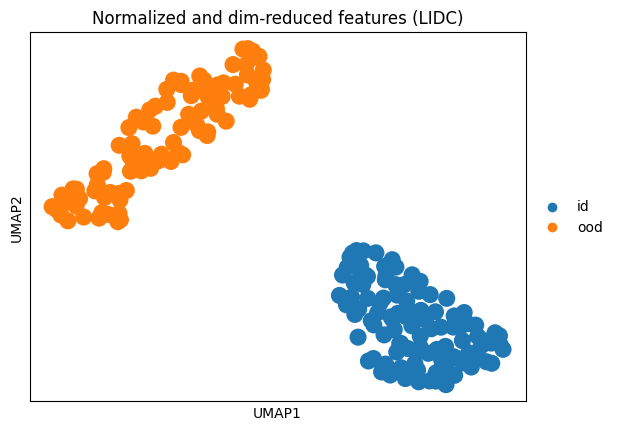

In [285]:
# plot umap

sc.pl.umap(adata, color=['sample_type'], title='Normalized and dim-reduced features (LIDC)', save=f'_{dataset_name}_spatial_fingerprints_umap.png')

# Data distribution

Text(0.5, 1.0, 'Transformed Data Distribution')

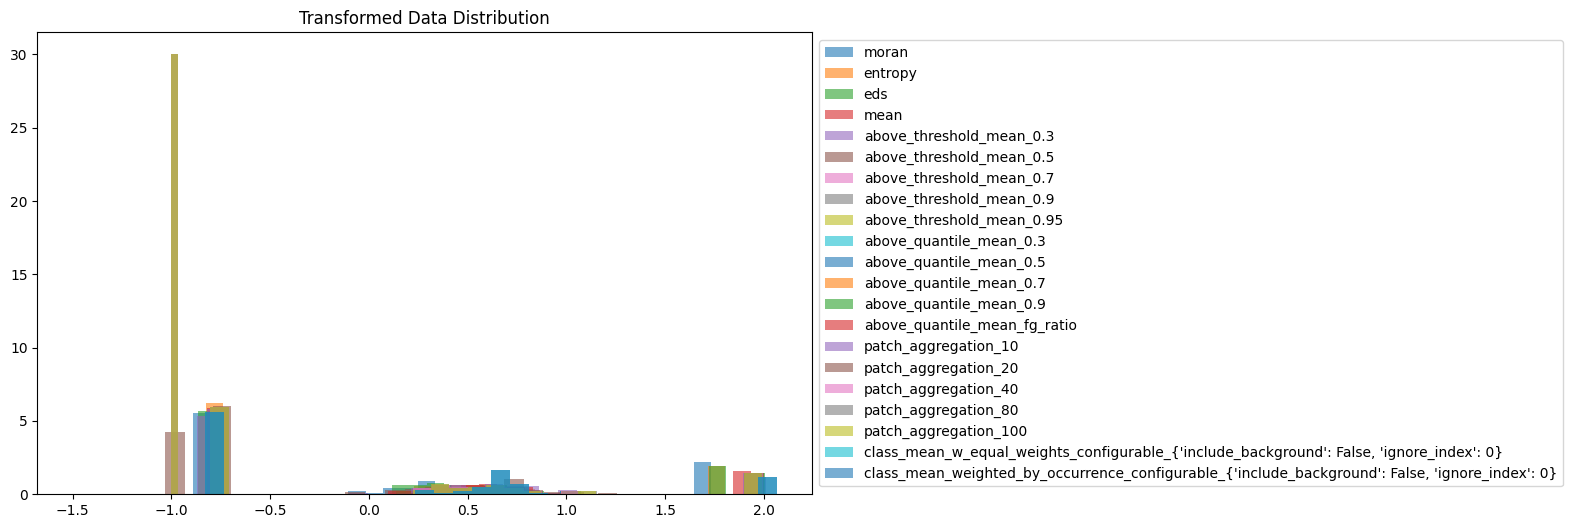

In [286]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))

id_fingerprints_transformed = id_fingerprints.copy()
trasnformation = {}

for sel_metric in id_fingerprints:
    data = id_fingerprints[sel_metric].values.flatten()
    
    # add small offset to avoid log(0)
    data = np.clip(data, a_min=1e-10, a_max=1-1e-10)
    data = norm.ppf(data)

    # norm with mean and std
    mean = data.mean()
    std = data.std()
    data = (data - mean) / std

    # store transformed data
    id_fingerprints[sel_metric] = data
    trasnformation[sel_metric] = (mean, std)
    plt.hist(data, bins=30, density=True, alpha=0.6, label=sel_metric)

# add legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Transformed Data Distribution')

Text(0.5, 1.0, 'Transformed Data Distribution')

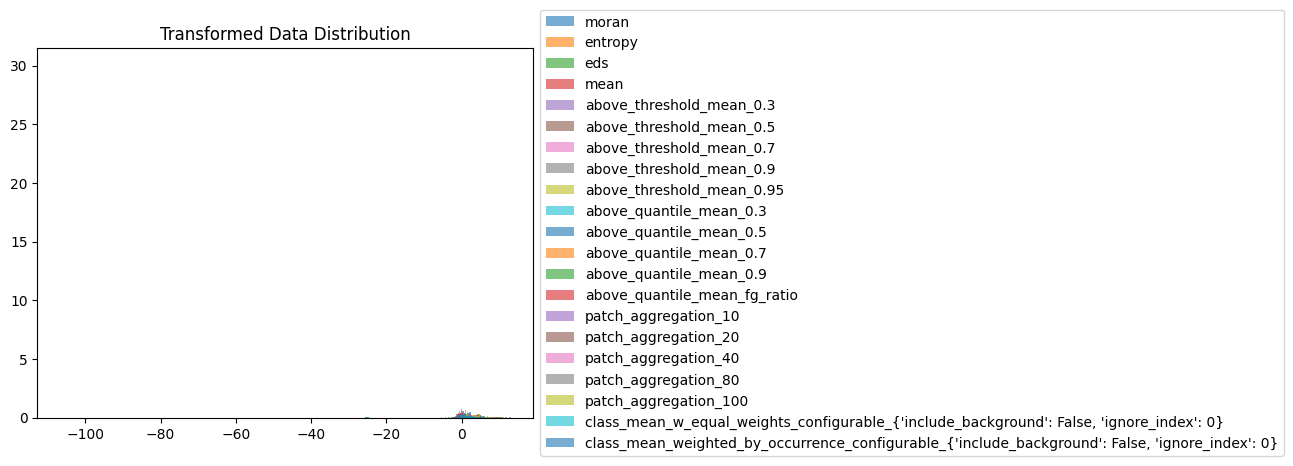

In [278]:
# transform ood_fingerprints using the same mean and std
ood_fingerprints_transformed = ood_fingerprints.copy()

for sel_metric in ood_fingerprints_transformed:
    mean, std = trasnformation[sel_metric]
    data = ood_fingerprints_transformed[sel_metric].values.flatten()
    data = np.clip(data, a_min=1e-10, a_max=1-1e-10)
    data = norm.ppf(data)
    data = (data - mean) / std
    ood_fingerprints_transformed[sel_metric] = data
    plt.hist(data, bins=30, density=True, alpha=0.6, label=sel_metric)

# add legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Transformed Data Distribution')

In [279]:
all_fingerprints_transformed = pd.concat([id_fingerprints, ood_fingerprints], axis=0)